<a href="https://colab.research.google.com/github/ND-CSE-30151/spring-2026/blob/main/notes/26-rice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 26: Rice's Theorem

<div class="alert alert-info">
    <p><b>Read</b> Theorems 5.2–4 and their proofs (pages 217–220).</b></p>
</div>

The next two theorems, 5.2 and 5.3, are a little different because they are not properties of a Turing machine and an input; they are properties of the whole language that a Turing machine recognizes. But the general scheme of their proofs is the same.

## Emptiness detection

Here, we walk through the proof of **Theorem 5.2**. It says that there is no "emptiness-detector" TM that decides whether another TM recognizes an empty language.

Suppose that there is an emptiness detector $R$. Then we need to implement a universal decider $S$.

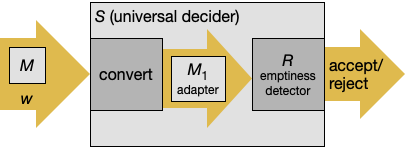

Since $S$ is supposed to be a universal decider, it will input a Turing machine $M$ and a string $w$. But it needs to make use of $R$, which inputs a Turing machine; call it $M_1$. So $S$ needs to "adapt" $M$ and $w$ into $M_1$. That is, depending on whether $M$ accepts $w$ or not, we need to make $M_1$ exhibit or not exhibit the behavior that $R$ knows how to detect.

Our $M_1$ is different from the book's; if you like the book's better, that's fine too.


### Proof

Suppose that there is an emptiness detector $R$. Then we implement a universal decider $S$, as follows.

$S =$ “On input $\langle M, w\rangle$:

1. Construct a Turing machine $M_1 =$ “On input $x$:

    - Run $M$ on input $w$.
    - If $M$ accepts $w$, then _accept_ $x$.
    - If $M$ rejects $w$, then _reject_ $x$.

2. Run $R$, the emptiness-detector, on $M_1$.
3. If $R$ accepts, that is, it detected an empty language, _reject_.
4. Otherwise, _accept_.

To see why $S$ decides $A_{\mathsf{TM}}$, we consider three cases:
- If $M$ accepts $w$, then $M_1$ accepts all strings $x$. That is, $M_1$ recognizes $\Sigma^\ast$, a nonempty language. So $R$ rejects $\langle M_1\rangle$, so $S$ accepts $\langle M, w\rangle$.
- If $M$ rejects $w$, then $M_1$ rejects all strings $x$. That is, $M_1$ recognizes $\emptyset$. So $R$ accepts $\langle M_1\rangle$, so $S$ rejects $\langle M, w\rangle$.
- If $M$ loops on $w$, then $M_1$ also loops on all strings $x$. So, $M_1$ recognizes $\emptyset$. So $R$ accepts $\langle M_1\rangle$, so $S$ rejects $\langle M, w\rangle$.

Thus $S$ decides $A_{\mathsf{TM}}$ as desired, which is a contradiction. We conclude that it's undecidable whether a given Turing machine recognizes the empty language.

### Two wrong proofs

**Question.** What would be wrong with this?

Suppose that there is an emptiness detector $R$. Then construct a universal decider $S =$“On input $\langle M, w\rangle$:

1. Run $M$ on input $w$.
2. If $M$ accepts $w$, let $M_1 =$‘On input $x$, reject $x$.’
3. Otherwise, let $M_1 =$‘On input $x$, accept $x$.’
4. Run $R$ on $\langle M_1\rangle$.
5. If $R$ accepts, then _accept_.
6. Otherwise, _reject_.

Then
- If $M$ accepts $w$, $M_1$ rejects all strings, so $R$ accepts $\langle M_1\rangle$, so $S$ accepts $\langle M, w\rangle$.
- Otherwise, $M_1$ accepts all strings, so $R$ rejects $\langle M_1\rangle$, so $S$ rejects $\langle M, w\rangle$.

So $S$ decides $A_{\mathsf{TM}}$, which is a contradiction. We conclude that it's undecidable whether a Turing machine recognizes the empty language.

**Question.** And what would be wrong with this?

Suppose that there is an emptiness detector $R$. Then we construct a universal decider $S =$ “On input $\langle M, w\rangle$:

1. Construct a Turing machine $M_1 =$ “On input $x$:

    - Run $M$ on input $w$.
    - If $M$ accepts $w$, then _reject_.
    - If $M$ rejects $w$, then _accept_.

2. Run $R$ on $M_1$.
3. If $R$ accepts, then _accept_.
4. Otherwise, _reject_.

Then
- If $M$ accepts $w$, then $M_1$ rejects all strings, so $R$ accepts $\langle M_1\rangle$, so $S$ accepts $\langle M, w\rangle$.
- Otherwise, $M_1$ accepts all strings, so $R$ rejects $\langle M_1\rangle$, so $S$ rejects $\langle M, w\rangle$.

So $S$ decides $A_{\mathsf{TM}}$, which is a contradiction. We conclude that it's undecidable whether a Turing machine recognizes the empty language.

## Rice's Theorem

We've tried to follow a general recipe for proving undecidability results. It turns out that this recipe can be distilled into a catch-all theorem called Rice's Theorem: any property of a language recognized by a Turing machine, as long as the property is not always true or always false, is undecidable.

There are some properties of the internal working of a Turing machine that are decidable (you'll see one in HW7). But broadly speaking, questions about external behaviors of computer programs tend to be undecidable. When you see problems like this in real life -- and you definitely will -- you should smell undecidability and think twice before trying to implement a solution to the problem.

## Other undecidable problems

Sometimes, the existence of a Turing machine simulator is not so obvious, and we have to think more carefully about it.

**Question**. An _unrestricted grammar_ is like a CFG, but the left-hand sides can be strings. A derivation starts with $S$ and continues until no more rules can be applied. Show that it is undecidable whether an unrestricted grammar generates a nonempty language. Hint: Convert $\langle M, w\rangle$ to a grammar whose starting rule generates the start configuration:
$$ S \rightarrow q_0 w $$
and for each transition of $M$, create a grammar rule (or rules) to simulate that transition.

See [the survey by Poonen](http://www-math.mit.edu/~poonen/papers/sampler.pdf) for more examples of undecidable problems.